# Exploratory Data Analysis (EDA)

This notebook performs EDA on the cloud resource optimization dataset. We will inspect the data, check for issues, and visualize key patterns before modeling.

## 1. Import Required Libraries

We will use pandas, numpy, matplotlib, and seaborn for data analysis and visualization.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Load Dataset

Load the dataset into a pandas DataFrame.

In [20]:
# Update the path if needed
DATA_PATH = '../archive/borg_traces_data.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


## 3. View Dataset Structure

Display the first few rows, shape, and data types.

In [21]:
df.head(), df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       405894 non-null  int64  
 1   time                             405894 non-null  int64  
 2   instance_events_type             405894 non-null  int64  
 3   collection_id                    405894 non-null  int64  
 4   scheduling_class                 405894 non-null  int64  
 5   collection_type                  405894 non-null  int64  
 6   priority                         405894 non-null  int64  
 7   alloc_collection_id              405894 non-null  int64  
 8   instance_index                   405894 non-null  int64  
 9   machine_id                       405894 non-null  int64  
 10  resource_request                 405120 non-null  str    
 11  constraint                       405894 non-null  str    
 12  collections_e

(   Unnamed: 0           time  instance_events_type  collection_id  \
 0           0              0                     2    94591244395   
 1           1  2517305308183                     2   260697606809   
 2           2   195684022913                     6   276227177776   
 3           3              0                     2    10507389885   
 4           4  1810627494172                     3    25911621841   
 
    scheduling_class  collection_type  priority  alloc_collection_id  \
 0                 3                1       200                    0   
 1                 2                0       360         221495397286   
 2                 2                0       103                    0   
 3                 3                0       200                    0   
 4                 2                0         0                    0   
 
    instance_index    machine_id  ... assigned_memory page_cache_memory  \
 0             144  168846390496  ...        0.014435          0.0004

## 4. Summary Statistics

View summary statistics for numerical columns.

In [22]:
df.describe()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,scheduler,start_time,end_time,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,failed
count,405894.000000,4.058940e+05,405894.000000,4.058940e+05,405894.000000,405894.000000,405894.000000,4.058940e+05,405894.000000,4.058940e+05,...,404935.000000,4.058940e+05,4.058940e+05,405894.000000,405894.000000,281206.000000,281206.000000,405894.000000,405894.000000,405894.000000
mean,202946.500000,6.927465e+13,2.945983,3.590897e+11,1.266870,0.087782,147.913793,7.021801e+10,5034.756259,8.491885e+10,...,0.370422,1.238422e+12,1.238634e+12,0.008927,0.000398,2.185379,0.010722,0.999223,4.563613,0.228331
std,117171.649419,2.507511e+16,2.045794,2.446122e+11,1.014087,0.282977,116.656633,1.673475e+11,11848.537486,1.377903e+11,...,0.482918,7.965088e+11,7.965134e+11,0.024937,0.000550,1.256117,0.007753,0.010239,2.208008,0.419757
min,0.000000,0.000000e+00,0.000000,6.824000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-1.000000e+00,...,0.000000,3.000000e+08,6.000000e+08,0.000000,0.000000,0.252846,0.000125,0.110000,1.000000,0.000000
25%,101473.250000,2.674747e+11,2.000000,2.125496e+11,0.000000,0.000000,103.000000,0.000000e+00,401.000000,2.932044e+09,...,0.000000,5.219700e+11,5.219710e+11,0.000196,0.000008,1.067229,0.004329,1.000000,3.000000,0.000000
50%,202946.500000,1.084800e+12,3.000000,3.108868e+11,1.000000,0.000000,105.000000,0.000000e+00,1380.000000,2.008985e+10,...,0.000000,1.274400e+12,1.274509e+12,0.002693,0.000227,1.918681,0.009506,1.000000,5.000000,0.000000
75%,304419.750000,1.766117e+12,5.000000,4.918812e+11,2.000000,0.000000,200.000000,0.000000e+00,4200.000000,1.318590e+11,...,1.000000,1.944000e+12,1.944300e+12,0.006683,0.000539,3.156894,0.016435,1.000000,6.000000,0.000000
max,405893.000000,9.223372e+18,10.000000,8.258532e+11,3.000000,1.000000,450.000000,7.426667e+11,177107.000000,8.254274e+11,...,1.000000,2.678400e+12,2.678700e+12,0.286133,0.008453,105.275932,0.084292,1.000000,8.000000,1.000000


## 5. Check for Missing Values

Identify missing values in each column.

In [23]:
df.isnull().sum()

Unnamed: 0                              0
time                                    0
instance_events_type                    0
collection_id                           0
scheduling_class                        0
collection_type                         0
priority                                0
alloc_collection_id                     0
instance_index                          0
machine_id                              0
resource_request                      774
constraint                              0
collections_events_type                 0
user                                    0
collection_name                         0
collection_logical_name                 0
start_after_collection_ids              0
vertical_scaling                      959
scheduler                             959
start_time                              0
end_time                                0
average_usage                           0
maximum_usage                           0
random_sample_usage               

## 6. Visualize Feature Distributions

Plot histograms and boxplots for numerical features.

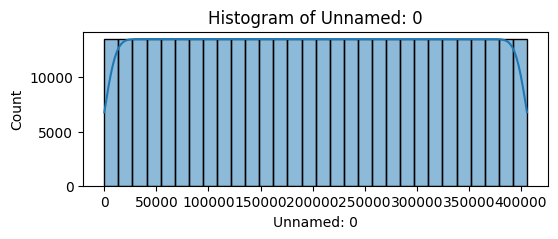

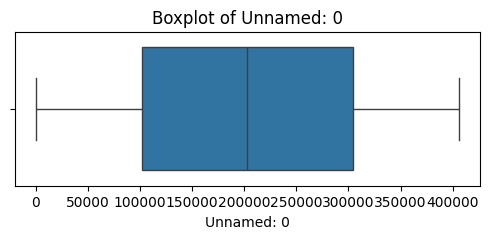

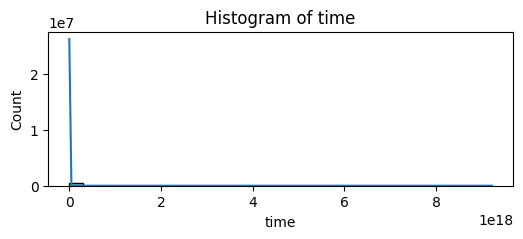

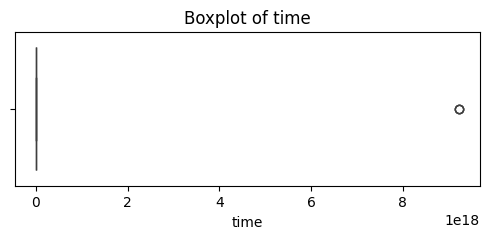

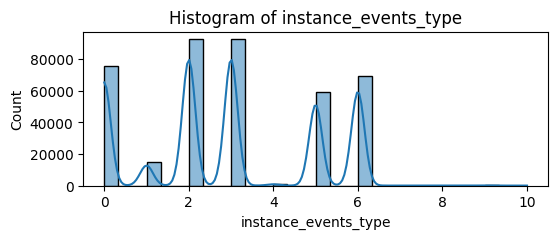

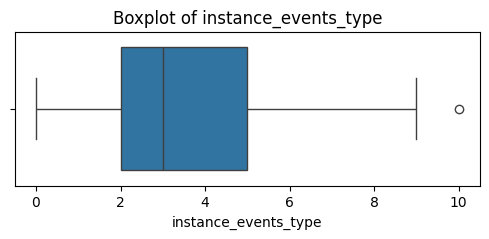

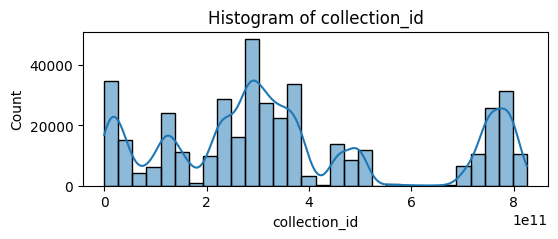

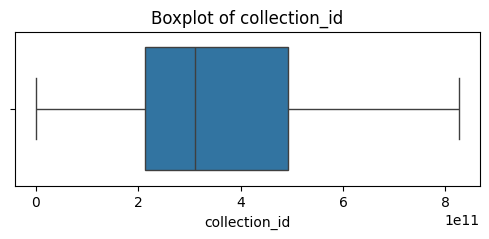

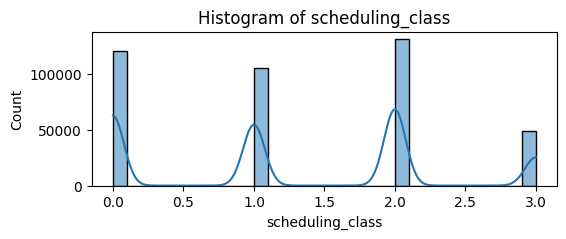

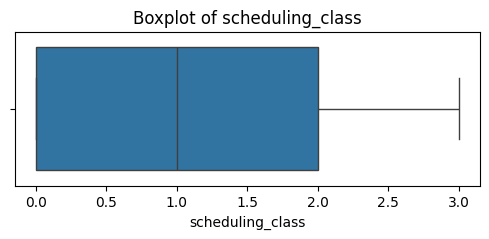

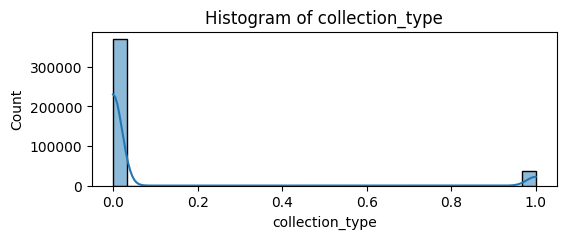

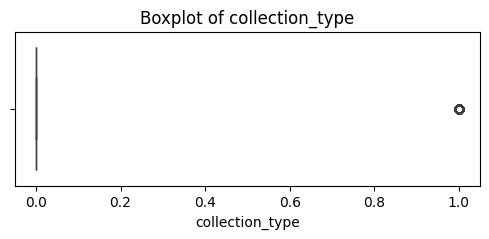

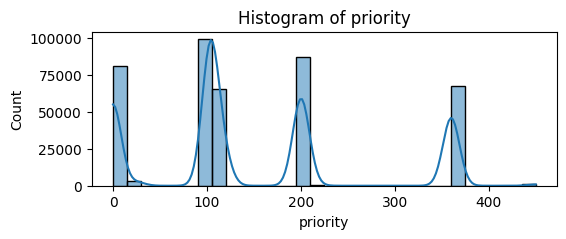

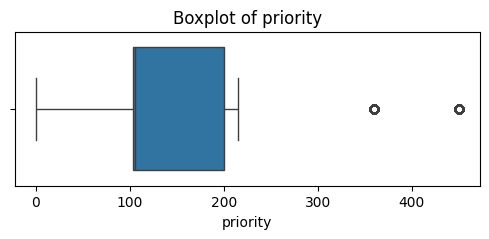

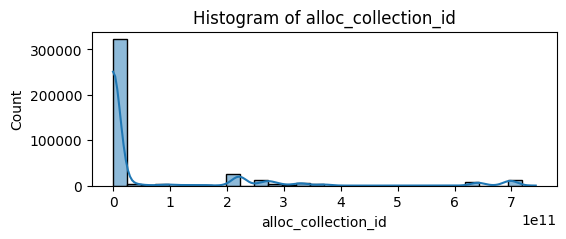

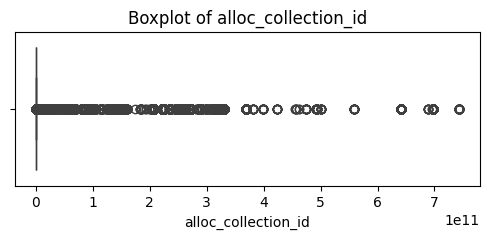

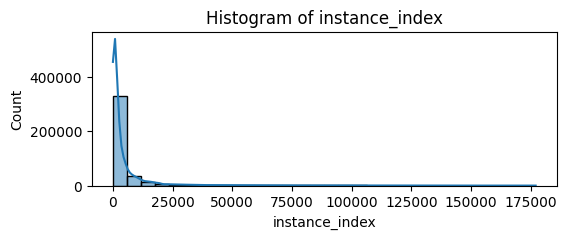

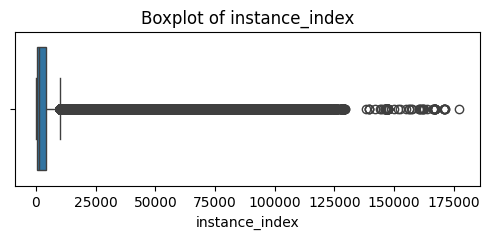

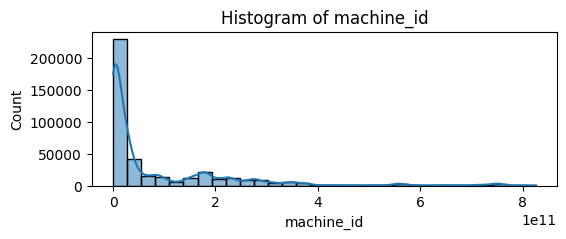

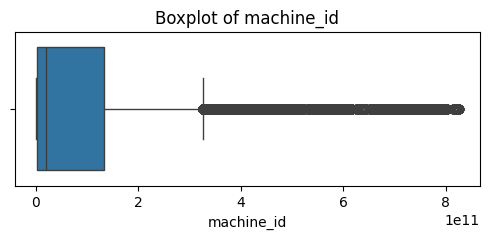

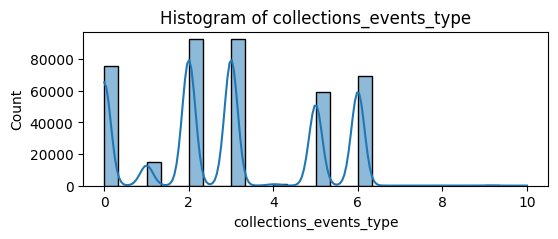

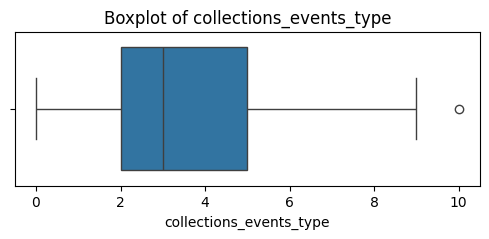

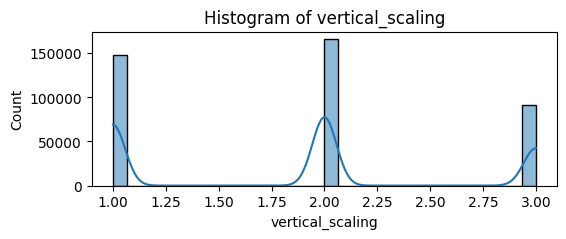

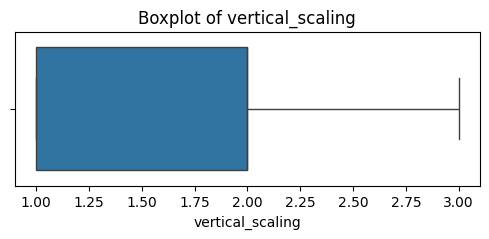

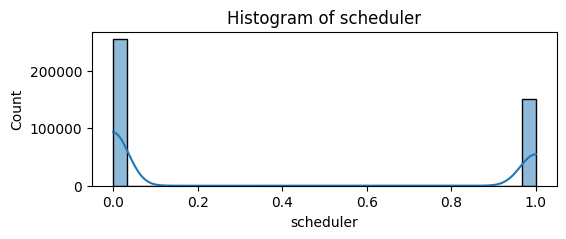

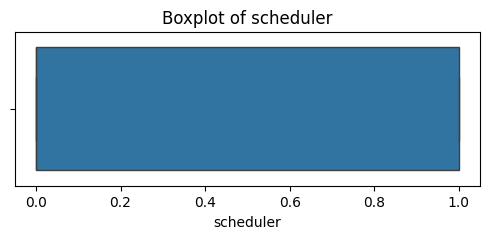

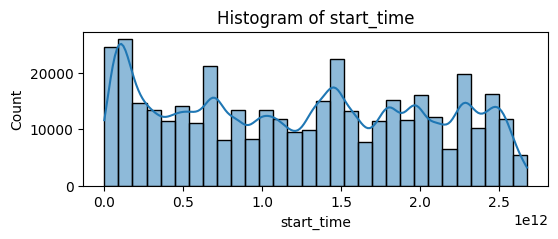

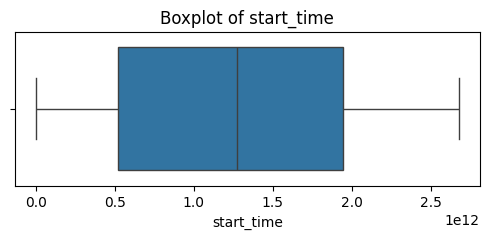

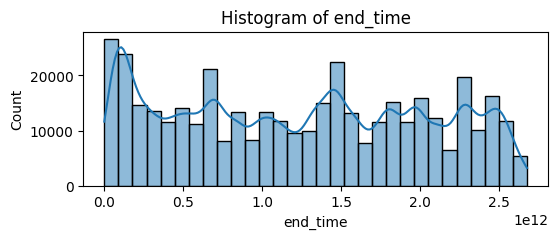

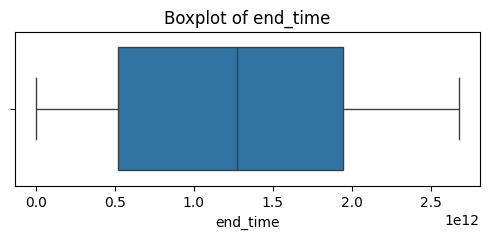

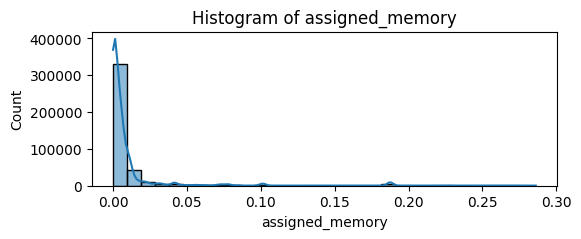

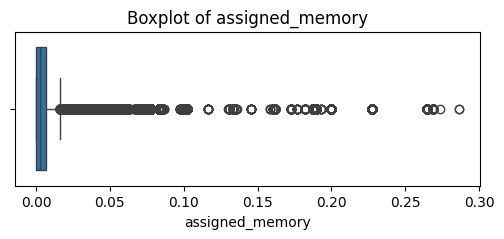

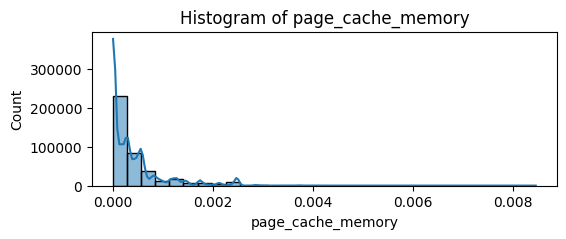

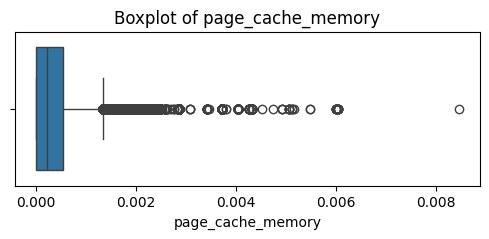

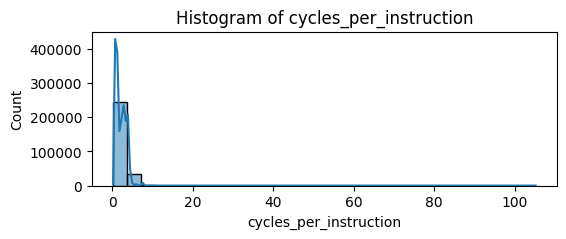

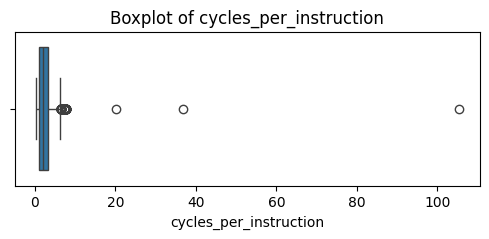

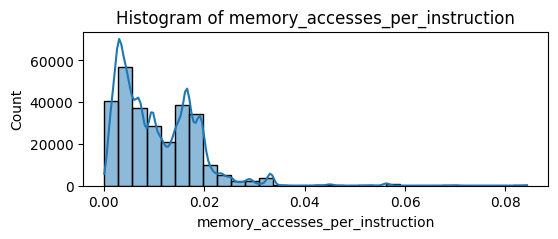

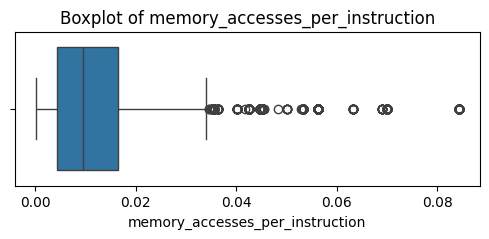

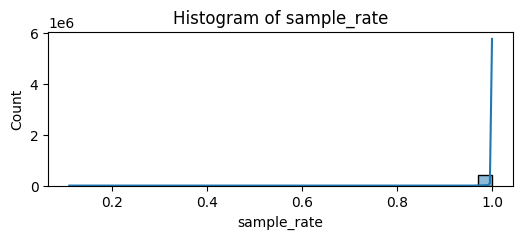

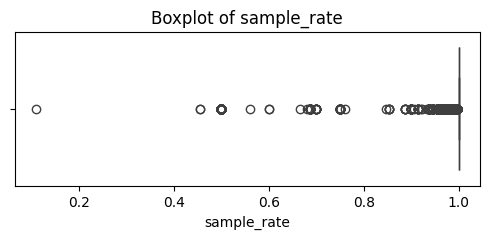

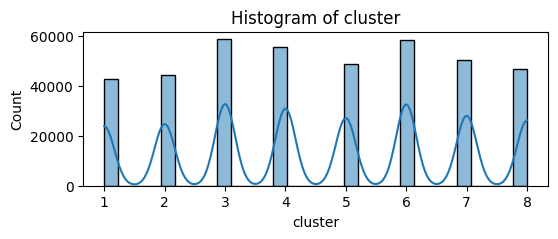

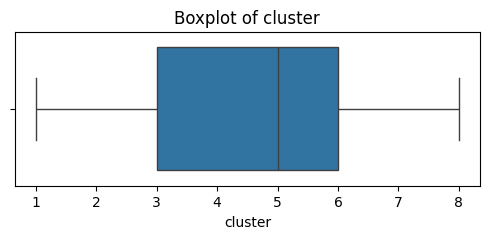

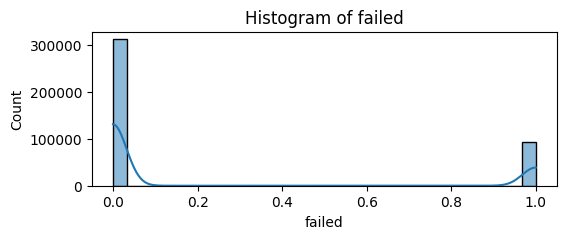

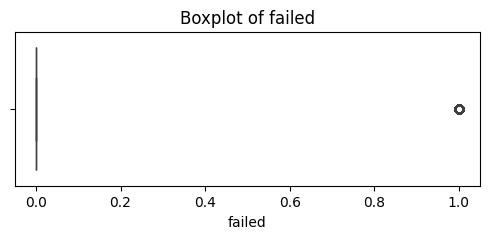

In [24]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 7. Correlation Analysis

Compute and visualize the correlation matrix.

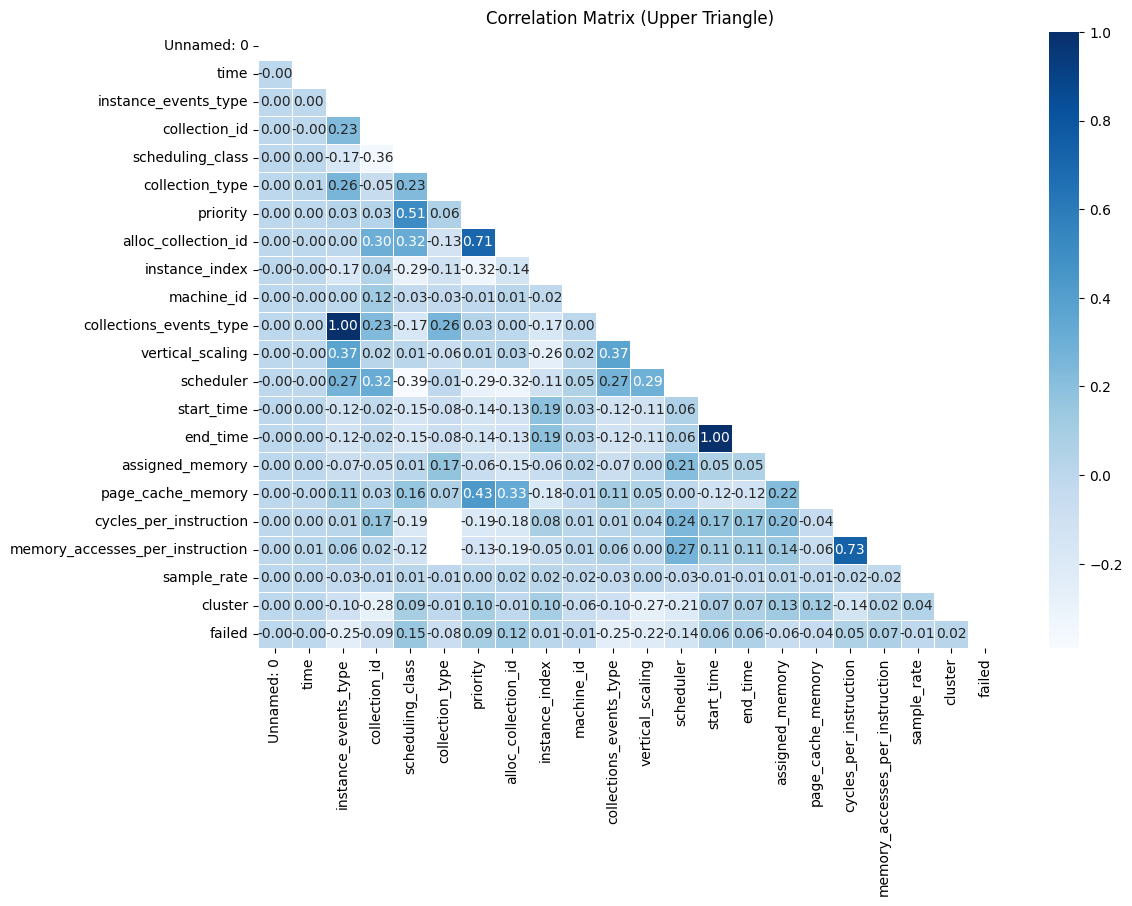

In [25]:
# Clean up correlation matrix for better readability
# Only show relevant numeric columns and round values
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12,8))
sns.heatmap(corr.round(2), annot=True, cmap='Blues', mask=mask, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Upper Triangle)')
plt.show()

## 8. Feature Engineering

Parse structured string columns into real numeric features, compute temporal lag/rolling features, and impute missing values.

In [26]:
import numpy as np
import pandas as pd

## ── Step 1: Parse string-array columns into numeric features ─────────────

def parse_array(s):
    """Parse a stringified numpy array like '[0.1 0.2 0.3]' into a numpy array."""
    try:
        return np.fromstring(s.strip('[]'), sep=' ')
    except Exception:
        return np.array([np.nan])

# ── cpu_usage_distribution: expand all percentile bins ────────────────────
cpu_arrays = df['cpu_usage_distribution'].apply(parse_array)
n_bins = int(cpu_arrays.dropna().iloc[0].shape[0])  # should be 11
for i in range(n_bins):
    df[f'cpu_dist_p{i}'] = cpu_arrays.apply(lambda x: x[i] if len(x) > i else np.nan)
df['cpu_dist_mean'] = cpu_arrays.apply(lambda x: x.mean() if not np.isnan(x).all() else np.nan)
df['cpu_dist_max']  = cpu_arrays.apply(lambda x: x.max()  if not np.isnan(x).all() else np.nan)
df['cpu_dist_std']  = cpu_arrays.apply(lambda x: x.std()  if not np.isnan(x).all() else np.nan)
df['cpu_dist_p95']  = cpu_arrays.apply(lambda x: np.percentile(x, 95) if not np.isnan(x).all() else np.nan)

# ── tail_cpu_usage_distribution ──────────────────────────────────────────
if 'tail_cpu_usage_distribution' in df.columns:
    tail_arrays = df['tail_cpu_usage_distribution'].apply(parse_array)
    df['tail_cpu_dist_mean'] = tail_arrays.apply(lambda x: x.mean() if not np.isnan(x).all() else np.nan)
    df['tail_cpu_dist_max']  = tail_arrays.apply(lambda x: x.max()  if not np.isnan(x).all() else np.nan)
    df['tail_cpu_dist_p95']  = tail_arrays.apply(lambda x: np.percentile(x, 95) if not np.isnan(x).all() else np.nan)

# ── average_usage / maximum_usage / random_sample_usage ───────────────────
def extract_struct_field(s, field):
    try:
        import ast
        d = ast.literal_eval(s)
        return float(d.get(field, np.nan))
    except Exception:
        return np.nan

for col_name, new_prefix in [('average_usage', 'avg'), ('maximum_usage', 'max_u'),
                               ('random_sample_usage', 'sample')]:
    if col_name in df.columns:
        df[f'{new_prefix}_cpu']    = df[col_name].apply(lambda s: extract_struct_field(s, 'cpus'))
        df[f'{new_prefix}_memory'] = df[col_name].apply(lambda s: extract_struct_field(s, 'memory'))

# ── Derive task duration ───────────────────────────────────────────────────
if 'start_time' in df.columns and 'end_time' in df.columns:
    df['task_duration'] = df['end_time'] - df['start_time']

print(f"New numeric columns added. Total columns: {df.shape[1]}")


New numeric columns added. Total columns: 59


In [27]:
## ── Step 2: Sort by time per machine (CRITICAL for lag/rolling) ──────────
df = df.sort_values(['machine_id', 'time']).reset_index(drop=True)

## ── Step 3: Temporal features using NUMERIC cpu_dist_mean ───────────────
# (NOT the string column cpu_usage_distribution — that caused the DataError!)
df['cpu_lag1']      = df.groupby('machine_id')['cpu_dist_mean'].shift(1)
df['cpu_lag2']      = df.groupby('machine_id')['cpu_dist_mean'].shift(2)
df['cpu_roll_mean'] = (
    df.groupby('machine_id')['cpu_dist_mean']
      .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

## ── Step 4: Impute missing values instead of dropping 31% of rows ────────
# Lag/rolling NaNs appear at the start of each machine's history.
# Machine-missing cycles_per_instruction (~31%) is also imputed here.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f"Shape after imputation: {df.shape}")
print(f"\nClass distribution (failed):")
print(df['failed'].value_counts(normalize=True).round(3))
print("\nNote: target is ~23% positive (failed). Use class_weight='balanced' or SMOTE before training.")


Shape after imputation: (405894, 62)

Class distribution (failed):
failed
0    0.772
1    0.228
Name: proportion, dtype: float64

Note: target is ~23% positive (failed). Use class_weight='balanced' or SMOTE before training.


## 9. Model Preparation

Select features, time-based train/test split, and standard scaling.

In [28]:
from sklearn.preprocessing import StandardScaler

## ── Step 5: Build feature list ──────────────────────────────────────────
dist_features = [f'cpu_dist_p{i}' for i in range(n_bins)]
stat_features = ['cpu_dist_mean', 'cpu_dist_max', 'cpu_dist_std', 'cpu_dist_p95']
temp_features = ['cpu_lag1', 'cpu_lag2', 'cpu_roll_mean']
base_features = ['assigned_memory', 'scheduling_class', 'priority']

optional_features = []
for col in ['avg_cpu', 'avg_memory', 'max_u_cpu', 'max_u_memory',
            'sample_cpu', 'sample_memory',
            'tail_cpu_dist_mean', 'tail_cpu_dist_max', 'tail_cpu_dist_p95',
            'task_duration']:
    if col in df.columns:
        optional_features.append(col)

features = dist_features + stat_features + temp_features + base_features + optional_features
features = [f for f in features if f in df.columns]
target   = 'failed'

## ── Step 6: Time-based train/test split ──────────────────────────────────
split = int(len(df) * 0.8)
train = df.iloc[:split]
test  = df.iloc[split:]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

## ── Step 7: Standardise features ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train_scaled.shape}")
print(f"Test  size : {X_test_scaled.shape}")
print(f"Features used ({len(features)}):")
for f in features:
    print(f"  {f}")


Train size : (324715, 31)
Test  size : (81179, 31)
Features used (31):
  cpu_dist_p0
  cpu_dist_p1
  cpu_dist_p2
  cpu_dist_p3
  cpu_dist_p4
  cpu_dist_p5
  cpu_dist_p6
  cpu_dist_p7
  cpu_dist_p8
  cpu_dist_p9
  cpu_dist_p10
  cpu_dist_mean
  cpu_dist_max
  cpu_dist_std
  cpu_dist_p95
  cpu_lag1
  cpu_lag2
  cpu_roll_mean
  assigned_memory
  scheduling_class
  priority
  avg_cpu
  avg_memory
  max_u_cpu
  max_u_memory
  sample_cpu
  sample_memory
  tail_cpu_dist_mean
  tail_cpu_dist_max
  tail_cpu_dist_p95
  task_duration


c:\Users\govin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\govin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\govin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
